<a href="https://colab.research.google.com/github/VuTuanAnh0949/RAG-LangChain-Ablation-Study/blob/main/RAG_Ablation_Semantic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Environment Setup


### 1.1 Install required packages

In [ ]:
!pip install -q \
  "langchain>=0.2.0" \
  "langchain-core>=0.2.0" \
  "langchain-community>=0.1.0" \
  "langchain-text-splitters>=0.2.0" \
  "sentence-transformers>=2.2.0" \
  "langchain-huggingface>=0.0.1" \
  "chromadb>=0.5.0" \
  "langchain-chroma>=0.2.0" \
  "pypdf" \
  "ragas>=0.2.0" \
  "datasets>=2.14.0" \
  "pandas" \
  "matplotlib" \
  "seaborn" \
  "openai>=1.0.0" \
  "langchain-openai>=0.1.0" \
  "gdown" \
  "tiktoken" \
  "nest_asyncio"\
  "underthesea"

### 1.2 Import libraries

In [ ]:
import os
import re
import json
import glob
import time
import gdown
import random
import asyncio
import unicodedata
import numpy as np
import pandas as pd
import seaborn as sns
import nest_asyncio
import matplotlib.pyplot as plt
from underthesea import sent_tokenize
from matplotlib.backends.backend_pdf import PdfPages

from tqdm import tqdm
from typing import List
from openai import OpenAI
from google.colab import userdata
from langchain_chroma import Chroma

from datasets import Dataset

from langchain_core.prompts import PromptTemplate
from langchain_core.documents import Document
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

from ragas import evaluate
from ragas.run_config import RunConfig
from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_precision,
    context_recall
)
from ragas.embeddings import LangchainEmbeddingsWrapper

nest_asyncio.apply()

/tmp/ipython-input-3758418960.py:37: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import (
/tmp/ipython-input-3758418960.py:37: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import (
/tmp/ipython-input-3758418960.py:37: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_precision
  from ragas.metrics import (
/tmp/ipython-input-3758418960.py:37: DeprecationWarning: Importing context_recall from 'ragas.metrics' is deprecated and will be removed

### 1.3 Set global seed for reproducibility (SEED = 42)

In [ ]:
SEED = 42

def set_global_seed(seed_value: int = 42):
    random.seed(seed_value)
    np.random.seed(seed_value)
    os.environ['PYTHONHASHSEED'] = str(seed_value)
    print(f"Global seed set to {seed_value}")

set_global_seed(SEED)

Global seed set to 42


### 1.4 Configure API Keys

In [ ]:
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

# os.environ["OPENAI_API_KEY"] = ""
OPENAI_API_KEY = os.environ["OPENAI_API_KEY"]

print("OpenAI API Key configured successfully")

OpenAI API Key configured successfully


### 1.5 Batch Processing Configuration

In [ ]:
BATCH_SIZE = 32
EMBEDDING_BATCH_SIZE = 100

LLM_MODEL = "gpt-4o-mini"
EMBEDDING_MODEL = "text-embedding-3-small"

SEMANTIC_BREAKPOINT_THRESHOLD = 0.5  # Increased from 0.3 to 0.5 for better semantic boundaries
MIN_CHUNK_SIZE = 600
MAX_CHUNK_SIZE = 1024
CHUNK_OVERLAP = 128  # Added explicit overlap parameter

EVAL_SAMPLE_SIZE = None
EVAL_MAX_WORKERS = 64
EVAL_TIMEOUT = 180

print(f"Configuration:")
print(f"  - LLM Model: {LLM_MODEL}")
print(f"  - Embedding Model: {EMBEDDING_MODEL}")
print(f"  - Batch Size: {BATCH_SIZE}")
print(f"  - Semantic Threshold: {SEMANTIC_BREAKPOINT_THRESHOLD}")
print(f"  - Chunk Overlap: {CHUNK_OVERLAP}")
print(f"  - RAGAS Eval Workers: {EVAL_MAX_WORKERS}")
print(f"  - Eval Sample Size: {'ALL' if EVAL_SAMPLE_SIZE is None else EVAL_SAMPLE_SIZE}")

Configuration:
  - LLM Model: gpt-4o-mini
  - Embedding Model: text-embedding-3-small
  - Batch Size: 32
  - Semantic Threshold: 0.5
  - Chunk Overlap: 128
  - RAGAS Eval Workers: 64
  - Eval Sample Size: ALL


## 2. Data Preparation


### 2.1 Download data

In [ ]:
!gdown 1Ebcv-0kq6_eF6QYfIMSL6ZXQUnETnWKW

Downloading...
From (original): https://drive.google.com/uc?id=1Ebcv-0kq6_eF6QYfIMSL6ZXQUnETnWKW
From (redirected): https://drive.google.com/uc?id=1Ebcv-0kq6_eF6QYfIMSL6ZXQUnETnWKW&confirm=t&uuid=510cd202-05f7-46f7-8b8b-2ba8332653bb
To: /content/RAG_DATA.zip
100% 133M/133M [00:02<00:00, 50.3MB/s]


In [ ]:
file_id = "1Ebcv-0kq6_eF6QYfIMSL6ZXQUnETnWKW"
zip_path = "/content/data.zip"
gdown.download(f"https://drive.google.com/uc?id={file_id}", zip_path, quiet=False)

!unzip -o /content/data.zip
DATA_DIR = "RAG_DATA"

Downloading...
From (original): https://drive.google.com/uc?id=1Ebcv-0kq6_eF6QYfIMSL6ZXQUnETnWKW
From (redirected): https://drive.google.com/uc?id=1Ebcv-0kq6_eF6QYfIMSL6ZXQUnETnWKW&confirm=t&uuid=ea2c512c-edf5-42cf-aa3e-a501eb2d0db6
To: /content/data.zip
100%|██████████| 133M/133M [00:01<00:00, 98.9MB/s]


Archive:  /content/data.zip
   creating: RAG_DATA/
  inflating: RAG_DATA/AI_Agents_Smolagents.pdf  
  inflating: RAG_DATA/AI_Image_Gen_Edit_CFM.pdf  
  inflating: RAG_DATA/AI_Linear_Algebra_NumPy_Practice.pdf  
  inflating: RAG_DATA/AI_Multi_Agent_Supervisor.pdf  
  inflating: RAG_DATA/AI_Problem_Solving.pdf  
  inflating: RAG_DATA/AI_Problem_Solving_Framework.pdf  
  inflating: RAG_DATA/AI_Vietnamese_Poetry.pdf  
  inflating: RAG_DATA/Applied_Statistics_AI.pdf  
  inflating: RAG_DATA/CNN_Exercise.pdf  
  inflating: RAG_DATA/Effective_Data_Presentation.pdf  
  inflating: RAG_DATA/Emoji_Generation_Stable_Diffusion.pdf  
  inflating: RAG_DATA/Git_DS_Roadmap.pdf  
  inflating: RAG_DATA/Hand_Gesture_Control_System_Tutorial.pdf  
  inflating: RAG_DATA/Interpolation_Missing_Data.pdf  
  inflating: RAG_DATA/LangChain_RAG_PDF_QA_Guide.pdf  
  inflating: RAG_DATA/LLM_Alignment_DPO.pdf  
  inflating: RAG_DATA/LLM_IT_SAT_Reading.pdf  
  inflating: RAG_DATA/LLM_Math_Reasoning_GRPO.pdf  
  inflatin

### 2.2 Download testing file

In [ ]:
file_id = "1a5RL7ex88w_5tZ1g6R31QTrfibvxqT_Q"
gdown.download(f"https://drive.google.com/uc?id={file_id}", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1a5RL7ex88w_5tZ1g6R31QTrfibvxqT_Q
To: /content/testset.json
100%|██████████| 312k/312k [00:00<00:00, 4.23MB/s]


'testset.json'

## 3. Model Configuration (API-based)


In [ ]:
def get_llm(
    model_name: str = LLM_MODEL,
    temperature: float = 0.0,
    max_tokens: int = 8192,
    seed: int = SEED,
):
    llm = ChatOpenAI(
        model=model_name,
        temperature=temperature,
        max_tokens=max_tokens,
        seed=seed,
        api_key=OPENAI_API_KEY,
    )
    print(f"✓ LLM initialized: {model_name} (seed={seed})")
    return llm


def get_embeddings(
    model_name: str = EMBEDDING_MODEL,
    chunk_size: int = EMBEDDING_BATCH_SIZE,
):
    embeddings = OpenAIEmbeddings(
        model=model_name,
        api_key=OPENAI_API_KEY,
        chunk_size=chunk_size,
    )
    print(f"Embeddings initialized: {model_name} (batch_size={chunk_size})")
    return embeddings

## 4. RAG Components


### 4.1 Define Vietnamese text cleaning function

In [ ]:
def clean_vietnamese_text(text: str) -> str:
    text = unicodedata.normalize('NFC', text)
    text = "".join(
        char for char in text
        if not unicodedata.category(char).startswith('C') or char in '\n\t'
    )
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'\n\s*\n', '\n', text)
    return text.strip()

### 4.2 Define document loader and text splitter

### 4.2 NEW - Semantic Chunking Implementation (FREE with HuggingFace)

In [ ]:
class SimpleLoader:
    """Load PDF documents and clean Vietnamese text"""
    def load_pdf(self, pdf_file: str):
        docs = PyPDFLoader(pdf_file, extract_images=True).load()
        for doc in docs:
            doc.page_content = clean_vietnamese_text(doc.page_content)
        return docs

    def load_dir(self, dir_path: str) -> List:
        pdf_files = glob.glob(f"{dir_path}/*.pdf")
        if not pdf_files:
            raise ValueError(f"No PDF files found in {dir_path}")

        all_docs = []
        for pdf_file in tqdm(pdf_files, desc="Loading PDFs"):
            try:
                all_docs.extend(self.load_pdf(pdf_file))
            except Exception as e:
                print(f"Error loading {pdf_file}: {e}")
        return all_docs


class SemanticChunker:
    """
    Semantic chunking using sentence embeddings and similarity thresholds.
    FIXED VERSION - Addresses all 6 critical issues from original implementation.
    """
    def __init__(
        self,
        embedding_model: str = EMBEDDING_MODEL,
        breakpoint_threshold: float = SEMANTIC_BREAKPOINT_THRESHOLD,
        overlap_size: int = CHUNK_OVERLAP,
    ):
        self.breakpoint_threshold = breakpoint_threshold
        self.overlap_size = overlap_size

        print(f"Loading embedding model: {embedding_model}...")
        self.embeddings = OpenAIEmbeddings(
            model=embedding_model,
            api_key=OPENAI_API_KEY
        )
        print(f"✓ Embedding model loaded successfully!")
        print(f"  - Threshold: {breakpoint_threshold}")
        print(f"  - Overlap: {overlap_size} chars")

    def _split_into_sentences(self, text: str) -> List[str]:
        """Split text into sentences using underthesea"""
        sentences = sent_tokenize(text)
        return [s.strip() for s in sentences if s.strip() and len(s) > 20]

    def _calculate_cosine_similarity(self, emb1, emb2):
        """Calculate cosine similarity between two embeddings"""
        return np.dot(emb1, emb2) / (np.linalg.norm(emb1) * np.linalg.norm(emb2))

    def _chunk_by_semantic_similarity(self, sentences: List[str]) -> List[str]:
        """
        Group sentences into chunks based on semantic similarity.
        FIX #1: Compare sentence i with sentence i-1 (not chunk vs sentence)
        FIX #2: Threshold increased to 0.5 (from 0.3)
        FIX #3: Batch embedding calls (compute all at once)
        """
        if not sentences:
            return []

        # FIX #3: Batch compute ALL embeddings at once (not in loop)
        print(f"  Computing embeddings for {len(sentences)} sentences in batch...")
        sentence_embeddings = self.embeddings.embed_documents(sentences)

        chunks = []
        current_chunk = [sentences[0]]

        for i in range(1, len(sentences)):
            # FIX #1: Compare sentence i with sentence i-1 (fair comparison)
            prev_emb = sentence_embeddings[i-1]
            curr_emb = sentence_embeddings[i]
            similarity = self._calculate_cosine_similarity(prev_emb, curr_emb)

            chunk_text = " ".join(current_chunk)
            chunk_len = len(chunk_text)

            # Force split if chunk too large
            if chunk_len >= MAX_CHUNK_SIZE:
                chunks.append(chunk_text)
                current_chunk = [sentences[i]]
            # FIX #2: Use threshold 0.5 (higher = stricter semantic boundaries)
            # Merge if similarity high OR chunk too small
            elif similarity >= self.breakpoint_threshold or chunk_len < MIN_CHUNK_SIZE:
                current_chunk.append(sentences[i])
            else:
                # Save current chunk and start new one
                chunks.append(chunk_text)
                current_chunk = [sentences[i]]

        # Add last chunk
        if current_chunk:
            chunks.append(" ".join(current_chunk))

        return chunks

    def split(self, documents) -> List:
        """
        Split documents into semantic chunks with proper overlap.
        FIX #5: Implement proper character-based overlap (120 chars)
        """
        all_chunks = []
        for doc in tqdm(documents, desc="Semantic chunking"):
            sentences = self._split_into_sentences(doc.page_content)

            if not sentences:
                continue

            chunks = self._chunk_by_semantic_similarity(sentences)

            # Create Document objects with proper overlap
            for idx, chunk_text in enumerate(chunks):
                if not chunk_text.strip():
                    continue

                # FIX #5: Add proper character-based overlap (like baseline)
                if idx > 0 and self.overlap_size > 0:
                    prev_chunk = chunks[idx-1]
                    # Take last N characters from previous chunk as overlap
                    if len(prev_chunk) >= self.overlap_size:
                        overlap = prev_chunk[-self.overlap_size:]
                        chunk_text = overlap + " " + chunk_text

                chunk_doc = Document(
                    page_content=chunk_text,
                    metadata=doc.metadata.copy()
                )
                all_chunks.append(chunk_doc)

        return all_chunks

### 4.3 Define vector database class (API Embeddings)

In [ ]:
class VectorDB:
    def __init__(
        self,
        documents=None,
        embedding=None,
        collection_name: str = "vietnamese_docs",
        persist_dir: str = "/content/chroma_data",
    ):
        self.persist_dir = persist_dir
        self.collection_name = collection_name
        self.embedding = embedding or get_embeddings()
        self.db = self._build_db(documents)

    def _build_db(self, documents):
        if documents is None or len(documents) == 0:
            db = Chroma(
                collection_name=self.collection_name,
                embedding_function=self.embedding,
                persist_directory=self.persist_dir,
            )
        else:
            print(f"Building vector database with {len(documents)} documents...")
            db = Chroma.from_documents(
                documents=documents,
                embedding=self.embedding,
                collection_name=self.collection_name,
                persist_directory=self.persist_dir,
            )
            print(f"✓ Vector database built successfully!")
        return db

    def get_retriever(self, search_kwargs: dict = None):
        if search_kwargs is None:
            search_kwargs = {"k": 3}

        return self.db.as_retriever(
            search_type="similarity",
            search_kwargs=search_kwargs,
        )

### 4.4 Define RAG pipeline with batch processing

In [ ]:
class FocusedAnswerParser(StrOutputParser):
    def parse(self, text: str) -> str:
        text = (text or "").strip()
        if "[TRẢ LỜI]:" in text:
            answer = text.split("[TRẢ LỜI]:")[-1].strip()
        else:
            answer = text

        answer = re.sub(r'^\s*[•\-\*]\s*', '', answer, flags=re.MULTILINE)
        answer = re.sub(r'\n+', ' ', answer).strip()
        return answer


class BatchRAG:
    def __init__(self, llm, batch_size: int = BATCH_SIZE):
        self.llm = llm
        self.batch_size = batch_size
        self.prompt_template = """Bạn là trợ lý AI phân tích tài liệu tiếng Việt.

[TÀI LIỆU]:
{context}

[CÂU HỎI]:
{question}

Hãy trả lời dựa trên tài liệu. Nếu tài liệu không có thông tin, nói rõ "Không có thông tin".
[TRẢ LỜI]:"""
        self.prompt = PromptTemplate.from_template(self.prompt_template)
        self.answer_parser = FocusedAnswerParser()

    def _format_docs(self, docs):
        formatted = []
        seen = set()
        for doc in docs:
            content = (doc.page_content or "").strip()
            if content and len(content) > 40 and content not in seen:
                formatted.append(content)
                seen.add(content)
        return "\n\n".join(formatted)

    def get_chain(self, retriever):
        def format_docs(docs):
            return self._format_docs(docs)

        rag_chain = (
            {"context": retriever | format_docs, "question": RunnablePassthrough()}
            | self.prompt
            | self.llm
            | self.answer_parser
        )
        return rag_chain

    def batch_retrieve(self, questions: List[str], retriever) -> List[dict]:
        all_contexts = []
        for question in tqdm(questions, desc="Retrieving documents"):
            docs = retriever.invoke(question)
            contexts = [(doc.page_content or "") for doc in docs]
            formatted_context = self._format_docs(docs)
            all_contexts.append({
                "question": question,
                "contexts": contexts,
                "formatted_context": formatted_context
            })
        return all_contexts

    def batch_generate(self, prompts: List[str]) -> List[str]:
        from langchain_core.messages import HumanMessage

        all_answers = []
        for i in tqdm(range(0, len(prompts), self.batch_size), desc="Generating answers"):
            batch = prompts[i:i + self.batch_size]

            messages_batch = [[HumanMessage(content=p)] for p in batch]
            batch_results = self.llm.batch(messages_batch)

            for result in batch_results:
                answer = self.answer_parser.parse(result.content)
                all_answers.append(answer)

        return all_answers

    def answer_with_contexts_batch(self, questions: List[str], retriever):
        print(f"Processing {len(questions)} questions in batches of {self.batch_size}...")
        retrieved_data = self.batch_retrieve(questions, retriever)
        prompts = [
            self.prompt.format(
                context=data["formatted_context"],
                question=data["question"]
            )
            for data in retrieved_data
        ]
        answers = self.batch_generate(prompts)

        results = []
        for data, answer in zip(retrieved_data, answers):
            results.append({
                "answer": answer,
                "contexts": data["contexts"]
            })

        return results

## 5. RAG System Initialization


In [ ]:
set_global_seed(SEED)

llm = get_llm(model_name=LLM_MODEL, seed=SEED)
embeddings = get_embeddings(model_name=EMBEDDING_MODEL, chunk_size=EMBEDDING_BATCH_SIZE)

loader = SimpleLoader()

chunker = SemanticChunker(
    embedding_model=EMBEDDING_MODEL,
    breakpoint_threshold=SEMANTIC_BREAKPOINT_THRESHOLD,
    overlap_size=CHUNK_OVERLAP
)

raw_docs = loader.load_dir(DATA_DIR)
split_docs = chunker.split(raw_docs)
print(f"Total documents: {len(raw_docs)}, Split chunks: {len(split_docs)}")

vdb = VectorDB(documents=split_docs, embedding=embeddings)
retriever = vdb.get_retriever(search_kwargs={"k": 3})

rag = BatchRAG(llm, batch_size=BATCH_SIZE)
rag_chain = rag.get_chain(retriever)

print("\n" + "="*50)
print("RAG System initialized successfully!")
print(f"  - LLM: {LLM_MODEL} (API)")
print(f"  - Embeddings: {EMBEDDING_MODEL} (API)")
print(f"  - Chunking: SEMANTIC FIXED (threshold={SEMANTIC_BREAKPOINT_THRESHOLD}, overlap={CHUNK_OVERLAP})")
print(f"  - Batch Size: {BATCH_SIZE}")
print(f"  - Seed: {SEED}")
print("="*50)

Global seed set to 42
✓ LLM initialized: gpt-4o-mini (seed=42)
Embeddings initialized: text-embedding-3-small (batch_size=100)
Loading embedding model: text-embedding-3-small...
✓ Embedding model loaded successfully!
  - Threshold: 0.5
  - Overlap: 128 chars


Semantic chunking:   0%|          | 0/1372 [00:00<?, ?it/s]

  Computing embeddings for 6 sentences in batch...


Semantic chunking:   0%|          | 1/1372 [00:02<57:43,  2.53s/it]

  Computing embeddings for 3 sentences in batch...


...

  Computing embeddings for 2 sentences in batch...


Semantic chunking: 100%|█████████▉| 1371/1372 [07:45<00:00,  3.22it/s]

  Computing embeddings for 5 sentences in batch...


Semantic chunking: 100%|██████████| 1372/1372 [07:45<00:00,  2.95it/s]


Total documents: 1372, Split chunks: 2332
Building vector database with 2332 documents...
✓ Vector database built successfully!

RAG System initialized successfully!
  - LLM: gpt-4o-mini (API)
  - Embeddings: text-embedding-3-small (API)
  - Chunking: SEMANTIC FIXED (threshold=0.5, overlap=128)
  - Batch Size: 32
  - Seed: 42


## 6. Evaluation


### 6.1 Load testing data from JSON

In [ ]:
testset_path = 'testset.json'

with open(testset_path, 'r', encoding='utf-8') as f:
    testset_data = json.load(f)

test_df = pd.DataFrame([
    {
        'user_input': item['user_input'],
        'reference': item['reference'],
        'reference_contexts': item['reference_contexts']
    }
    for item in testset_data
])

print(f"Loaded {len(test_df)} test questions from testset.json")
display(test_df.head())

Loaded 52 test questions from testset.json


,user_input,reference,reference_contexts
0,Máy học là gì và nó có vai trò gì trong phân l...,Máy học là một lĩnh vực phổ biến trong phân lo...,[I. Giới thiệu** **Text Classification (Tạm dị...
1,Cơ sở dữ liệu Vector là gì và nó được sử dụng ...,Cơ sở dữ liệu Vector được sử dụng trong việc x...,[II.2. Cài đặt và Import thư viện . . . . . . ...
2,What is the significance of the FA Cup in the ...,The FA Cup is mentioned in a spam message that...,[. . . . . . . . . . . . . . . . . . . 14 III....
3,What libraries are commonly used in AI VIET NA...,"In AI VIET NAM, commonly used libraries for na...",[Text FA to 87121 to receive entr...| |spam|Fr...
4,What are the key steps involved in the data pr...,The key steps involved in the data preprocessi...,"[phần đặc trưng và nhãn, sau khi có dataframe,..."


### 6.2 Run batch predictions on test questions (API)

In [ ]:
set_global_seed(SEED)

print(f"LLM: {LLM_MODEL}")
print(f"Batch size: {BATCH_SIZE}")

questions = test_df['user_input'].tolist()

start_time = time.time()
batch_results = rag.answer_with_contexts_batch(questions, retriever)
elapsed_time = time.time() - start_time

print(f"Inference completed in {elapsed_time:.2f} seconds")
print(f"Average time per question: {elapsed_time/len(questions):.2f} seconds")

results = []
for idx, (result, (_, row)) in enumerate(zip(batch_results, test_df.iterrows())):
    results.append({
        "user_input": row['user_input'],
        "response": result["answer"],
        "retrieved_contexts": result["contexts"],
        "reference": row.get('reference', ''),
        "reference_contexts": row.get('reference_contexts', [])
    })

eval_df = pd.DataFrame(results)
print(f"Collected {len(eval_df)} predictions")
display(eval_df.head())

Global seed set to 42
LLM: gpt-4o-mini
Batch size: 32
Processing 52 questions in batches of 32...


Generating answers: 100%|██████████| 2/2 [00:43<00:00, 21.61s/it]

Inference completed in 55.97 seconds
Average time per question: 1.08 seconds
Collected 52 predictions


,user_input,response,retrieved_contexts,reference,reference_contexts
0,Máy học là gì và nó có vai trò gì trong phân l...,Máy học (machine learning) là một lĩnh vực tro...,[phân loại văn bản. Học máy Sử dụng để xây dựn...,Máy học là một lĩnh vực phổ biến trong phân lo...,[I. Giới thiệu** **Text Classification (Tạm dị...
1,Cơ sở dữ liệu Vector là gì và nó được sử dụng ...,Cơ sở dữ liệu Vector là một hệ thống lưu trữ c...,[AI VIET NAM (AIO2025) aivietnam.edu.vn III. X...,Cơ sở dữ liệu Vector được sử dụng trong việc x...,[II.2. Cài đặt và Import thư viện . . . . . . ...
2,What is the significance of the FA Cup in the ...,Không có thông tin.,[ tkts 21st May 2005. Text FA to 87121 to rece...,The FA Cup is mentioned in a spam message that...,[. . . . . . . . . . . . . . . . . . . 14 III....
3,What libraries are commonly used in AI VIET NA...,Các thư viện thường được sử dụng trong AI VIET...,[AI VIET NAM (AIO2025) aivietnam.edu.vn • stri...,"In AI VIET NAM, commonly used libraries for na...",[Text FA to 87121 to receive entr...| |spam|Fr...
4,What are the key steps involved in the data pr...,Các bước chính trong tiền xử lý dữ liệu cho AI...,[AI VIETNAM (AIO2024) aivietnam.edu.vn • Crawl...,The key steps involved in the data preprocessi...,"[phần đặc trưng và nhãn, sau khi có dataframe,..."


### 6.3 Evaluate RAG with RAGAS metrics (⚡ Optimized for Speed)

In [ ]:
if EVAL_SAMPLE_SIZE is not None:
    eval_subset = eval_df.sample(n=min(EVAL_SAMPLE_SIZE, len(eval_df)), random_state=SEED)
    print(f"Quick evaluation mode: Using {len(eval_subset)} samples")
else:
    eval_subset = eval_df
    print(f"Full evaluation: Using all {len(eval_subset)} samples")

eval_dataset = Dataset.from_pandas(eval_subset.reset_index(drop=True))

wrapped_embeddings = LangchainEmbeddingsWrapper(
    OpenAIEmbeddings(model='text-embedding-3-small')
)

run_config = RunConfig(
    max_workers=EVAL_MAX_WORKERS,
    timeout=EVAL_TIMEOUT,
    max_retries=1,
    max_wait=60,
)

print(f"Running RAGAS evaluation...")
print(f"   - Parallel workers: {EVAL_MAX_WORKERS}")
print(f"   - Samples: {len(eval_subset)}")

start_time = time.time()

ragas_results = evaluate(
    dataset=eval_dataset,
    metrics=[
        faithfulness,
        answer_relevancy,
        context_precision,
        context_recall
    ],
    embeddings=wrapped_embeddings,
    run_config=run_config,
    raise_exceptions=False,
)

eval_time = time.time() - start_time
print(f"\nEvaluation completed in {eval_time:.1f} seconds")
print(f"  Average: {eval_time/len(eval_subset):.2f}s per sample")

print("=== RAGAS SCORES ===")
print(ragas_results)

Full evaluation: Using all 52 samples
Running RAGAS evaluation...
   - Parallel workers: 64
   - Samples: 52


/tmp/ipython-input-3311990745.py:10: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  wrapped_embeddings = LangchainEmbeddingsWrapper(


Evaluating:   0%|          | 0/208 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[80]: InstructorRetryException(<failed_attempts>

<generation number="1">
<exception>
    The output is incomplete due to a max_tokens length limit.
</exception>
<completion>
    ChatCompletion(id='chatcmpl-CsBaWvbnywoEZWVG5aMLOJ3wUmpCi', choices=[Choice(finish_reason='length', index=0, logprobs=None, message=ChatCompletionMessage(content='{\n    "statements": [\n        {\n            "statement": "Để xác định đúng vấn đề trong dự án AI, cần thực hiện các bước sau.",\n            "reason": "The context discusses the importance of correctly identifying the problem in AI projects but does not specify the steps to do so.",\n            "verdict": 0\n        },\n        {\n            "statement": "Bắt đầu từ vấn đề kinh doanh cụ thể là bước đầu tiên.",\n            "reason": "The context mentions starting from a specific business problem as a key aspect but does not explicitly state it as the first step.",\n            "verdict": 0\n        },\


Evaluation completed in 1731.8 seconds
  Average: 33.30s per sample
=== RAGAS SCORES ===
{'faithfulness': 0.8090, 'answer_relevancy': 0.6110, 'context_precision': 0.8301, 'context_recall': 0.6285}


### 6.4 Visualize evaluation results

PDF saved: RAGAS_Evaluation_Semantic_Chunking.pdf


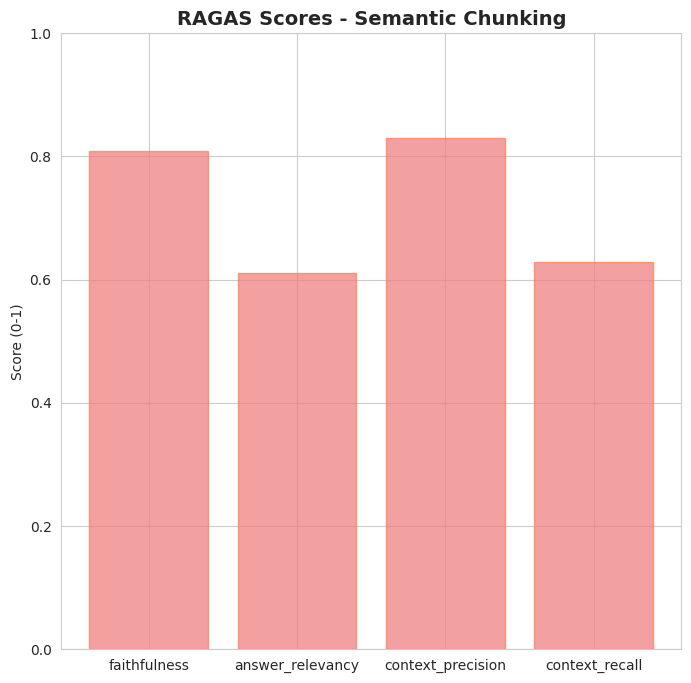

In [ ]:
results_df = ragas_results.to_pandas()
pdf_filename = "RAGAS_Evaluation_Semantic_Chunking.pdf"

with PdfPages(pdf_filename) as pdf:
    sns.set_style("whitegrid")
    fig1 = plt.figure(figsize=(8, 8))

    metric_cols = [col for col in ['faithfulness', 'answer_relevancy', 'context_precision', 'context_recall']
                   if col in results_df.columns]

    if metric_cols:
        scores = {col: results_df[col].mean() for col in metric_cols}
        plt.bar(scores.keys(), scores.values(), color='lightcoral', edgecolor='coral', alpha=0.75)
        plt.title("RAGAS Scores - Semantic Chunking", fontsize=14, fontweight='bold')
        plt.ylabel("Score (0-1)")
        plt.ylim(0, 1)

    if metric_cols:
        stats_df = results_df[metric_cols].describe().round(3)
        fig2 = plt.figure(figsize=(10, 6))
        plt.axis('off')
        plt.title("Detailed Statistics", fontsize=16, fontweight='bold', pad=20)

        table = plt.table(cellText=stats_df.values,
                          colLabels=stats_df.columns,
                          rowLabels=stats_df.index,
                          loc='center',
                          cellLoc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1.2, 1.2)

        pdf.savefig(fig2)
        plt.close(fig2)

print(f"PDF saved: {pdf_filename}")

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
import pandas as pd

# 1. Chuyển đổi kết quả Ragas sang DataFrame
# (Giả sử bạn đã có biến 'ragas_results' từ bước đánh giá trước đó)
results_df = ragas_results.to_pandas()

# Đặt tên cho 2 file riêng biệt
chart_filename = "RAGAS_Evaluation_Semantic_Chunking_Chart.pdf"
table_filename = "RAGAS_Evaluation_Semantic_Chunking_Table.pdf"

# ==========================================================
# PHẦN 1: IN CHART (GIỮ NGUYÊN CODE CỦA BẠN)
# ==========================================================
with PdfPages(chart_filename) as pdf:
    # Thiết lập style cho đẹp
    sns.set_style("whitegrid")

    # Tạo Figure mới
    fig1 = plt.figure(figsize=(8, 8))

    # Xác định các cột metrics cần vẽ
    target_cols = ['faithfulness', 'answer_relevancy', 'context_precision', 'context_recall']
    metric_cols = [col for col in target_cols if col in results_df.columns]

    if metric_cols:
        # Tính giá trị trung bình cho từng metric
        scores = {col: results_df[col].mean() for col in metric_cols}

        # Vẽ biểu đồ cột
        plt.bar(scores.keys(), scores.values(), color='lightcoral', edgecolor='coral', alpha=0.75)

        # Trang trí biểu đồ
        plt.title("RAGAS Scores - Semantic Chunking", fontsize=14, fontweight='bold')
        plt.ylabel("Score (0-1)")
        plt.ylim(0, 1) # Giới hạn trục Y từ 0 đến 1

        # Thêm nhãn giá trị lên đầu mỗi cột (Optional - để dễ nhìn hơn)
        for i, v in enumerate(scores.values()):
            plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontweight='bold')

        # --- LƯU BIỂU ĐỒ VÀO PDF ---
        pdf.savefig(fig1)

    # Đóng figure sau khi lưu xong
    plt.close(fig1)

print(f"✅ Đã lưu Chart vào file: {chart_filename}")


# ==========================================================
# PHẦN 2: IN TABLE (FILE RIÊNG)
# ==========================================================
with PdfPages(table_filename) as pdf:
    # Xác định các cột metrics để thống kê
    target_cols = ['faithfulness', 'answer_relevancy', 'context_precision', 'context_recall']
    metric_cols = [col for col in target_cols if col in results_df.columns]

    if metric_cols:
        # Tạo bảng thống kê mô tả (Mean, Std, Min, Max...)
        stats_df = results_df[metric_cols].describe().round(3)

        # Tạo Figure cho bảng
        fig2 = plt.figure(figsize=(10, 6))

        # Tắt trục tọa độ vì đây là bảng
        plt.axis('off')
        plt.title("Detailed Statistics Table", fontsize=16, fontweight='bold', pad=20)

        # Vẽ bảng
        table = plt.table(cellText=stats_df.values,
                          colLabels=stats_df.columns,
                          rowLabels=stats_df.index,
                          loc='center',
                          cellLoc='center')

        # Chỉnh font và kích thước bảng cho dễ nhìn
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1.2, 1.5) # Kéo giãn bảng

        # Lưu bảng vào PDF
        pdf.savefig(fig2)

        # Đóng figure
        plt.close(fig2)

print(f"✅ Đã lưu Table vào file: {table_filename}")

✅ Đã lưu Chart vào file: RAGAS_Evaluation_Semantic_Chunking_Chart.pdf
✅ Đã lưu Table vào file: RAGAS_Evaluation_Semantic_Chunking_Table.pdf


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
import pandas as pd
import matplotlib

# --- CẤU HÌNH FONT TIMES NEW ROMAN ---
# Thiết lập font chữ chung cho toàn bộ biểu đồ là Times New Roman
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.serif'] = ['Times New Roman']

# 1. Chuyển đổi kết quả Ragas sang DataFrame
# (Giả sử bạn đã có biến 'ragas_results' từ bước đánh giá trước đó)
results_df = ragas_results.to_pandas()

# Đặt tên cho 2 file riêng biệt
chart_filename = "RAGAS_Evaluation_Semantic_Chunking_Chart.pdf"
table_filename = "RAGAS_Evaluation_Semantic_Chunking_Table.pdf"

# ==========================================================
# PHẦN 1: IN CHART (GIỮ NGUYÊN CODE CỦA BẠN, CHỈ ĐỔI FONT)
# ==========================================================
with PdfPages(chart_filename) as pdf:
    # Thiết lập style cho đẹp (nhưng vẫn giữ font serif đã set ở trên)
    sns.set_style("whitegrid", {'font.family': 'serif', 'font.serif': ['Times New Roman']})

    # Tạo Figure mới
    fig1 = plt.figure(figsize=(8, 8))

    # Xác định các cột metrics cần vẽ
    target_cols = ['faithfulness', 'answer_relevancy', 'context_precision', 'context_recall']
    metric_cols = [col for col in target_cols if col in results_df.columns]

    if metric_cols:
        # Tính giá trị trung bình cho từng metric
        scores = {col: results_df[col].mean() for col in metric_cols}

        # Vẽ biểu đồ cột
        plt.bar(scores.keys(), scores.values(), color='lightcoral', edgecolor='coral', alpha=0.75)

        # Trang trí biểu đồ
        plt.title("RAGAS Scores - Semantic Chunking", fontsize=14, fontweight='bold')
        plt.ylabel("Score (0-1)")
        plt.ylim(0, 1) # Giới hạn trục Y từ 0 đến 1

        # Thêm nhãn giá trị lên đầu mỗi cột (Optional - để dễ nhìn hơn)
        for i, v in enumerate(scores.values()):
            plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontweight='bold')

        # --- LƯU BIỂU ĐỒ VÀO PDF ---
        pdf.savefig(fig1)

    # Đóng figure sau khi lưu xong
    plt.close(fig1)

print(f"✅ Đã lưu Chart vào file: {chart_filename}")


# ==========================================================
# PHẦN 2: IN TABLE (FILE RIÊNG)
# ==========================================================
with PdfPages(table_filename) as pdf:
    # Xác định các cột metrics để thống kê
    target_cols = ['faithfulness', 'answer_relevancy', 'context_precision', 'context_recall']
    metric_cols = [col for col in target_cols if col in results_df.columns]

    if metric_cols:
        # Tạo bảng thống kê mô tả (Mean, Std, Min, Max...)
        stats_df = results_df[metric_cols].describe().round(3)

        # Tạo Figure cho bảng
        fig2 = plt.figure(figsize=(10, 6))

        # Tắt trục tọa độ vì đây là bảng
        plt.axis('off')
        plt.title("Detailed Statistics Table", fontsize=16, fontweight='bold', pad=20)

        # Vẽ bảng
        table = plt.table(cellText=stats_df.values,
                          colLabels=stats_df.columns,
                          rowLabels=stats_df.index,
                          loc='center',
                          cellLoc='center')

        # Chỉnh font và kích thước bảng cho dễ nhìn
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1.2, 1.5) # Kéo giãn bảng

        # Lưu bảng vào PDF
        pdf.savefig(fig2)

        # Đóng figure
        plt.close(fig2)

print(f"✅ Đã lưu Table vào file: {table_filename}")

✅ Đã lưu Chart vào file: RAGAS_Evaluation_Semantic_Chunking_Chart.pdf


✅ Đã lưu Table vào file: RAGAS_Evaluation_Semantic_Chunking_Table.pdf
